# Simple Linear Regression

## What is Simple Linear Regression?

**Linear regression** is one of the most fundamental algorithms in machine learning. It models the relationship between an input variable (called a **feature** or **predictor**) and a continuous output variable (called the **target** or **label**) as a straight line.

**Simple** linear regression means we use **exactly one** input feature to predict the output. (When you have multiple features, it's called *multiple* linear regression.)

The model is just the equation of a line:

$$\hat{y} = \theta_0 + \theta_1 x$$

Where:
- $x$ is the input feature (e.g. engine size)
- $\hat{y}$ is the predicted output (e.g. CO2 emissions)
- $\theta_0$ is the **intercept** — the predicted value when $x = 0$
- $\theta_1$ is the **slope (coefficient)** — how much $\hat{y}$ changes for each 1-unit increase in $x$

**Training** the model means finding the values of $\theta_0$ and $\theta_1$ that minimize the error between the predicted values $\hat{y}$ and the actual values $y$ across all training examples. The most common way to measure this error is **Mean Squared Error (MSE)**.

---

**Objectives:**

- Use scikit-learn to implement simple linear regression
- Create, train, and test a linear regression model on real data

## Install needed packages

For this lab, we'll need to install the following packages:
- Numpy
- Matplotlib
- Pandas
- Scikit-learn

Run `uv pip install -r requirements.txt` to install them.

## Import the libraries

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Render matplotlib plots as static images

`%matplotlib inline` is a Jupyter magic command. It tells the notebook
to render matplotlib plots as static images directly inside the notebook output,
rather than opening a separate window.

In [28]:
%matplotlib inline

## Load dataset

The dataset we will use is stored in the `fuel_consumption_co2.csv` file.

We'll use the file path with the Pandas library to load the dataset.

In [29]:
df = pd.read_csv('fuel_consumption_co2.csv')

In [30]:
# Verify successful dataset load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
34,2014,AUDI,A8L,FULL-SIZE,4.0,8,AS8,Z,14.7,9.7,12.5,23,288
946,2014,SUBARU,FORESTER AWD,SUV - SMALL,2.5,4,M6,X,10.9,8.3,9.7,29,223
145,2014,BUICK,LACROSSE,MID-SIZE,3.6,6,AS6,E,18.4,12.2,15.6,18,250
832,2014,NISSAN,370Z,TWO-SEATER,3.7,6,AS7,Z,12.6,9.1,11.0,26,253
216,2014,CHEVROLET,EXPRESS 1500 CARGO CONV,VAN - CARGO,5.3,8,A4,E,23.9,18.5,21.5,13,344



## Understand the data

### `fuel_consumption_co2.csv`

We will use a fuel consumption dataset, `fuel_consumption_co2.csv`,
which contains model-specific fuel consumption ratings and estimated carbon
dioxide emissions for new light-duty vehicles for retail sale in Canada.

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182

Our task is to create a simple linear regression model from one of these
features to predict CO2 emissions of unobserved cars based on that feature.


### Explore the data

First, let's consider a statistical summary of the data.


In [31]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency
between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much
higher than the rest. This could either be a valid reading for a highly
efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information
content.


#### Select features
Select a few features that might be indicative of CO2 emission to explore more.


In [32]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
754,5.5,8,18.2,419
496,1.5,4,7.5,172
557,5.0,8,17.5,280
9,2.4,4,9.2,212
841,4.0,6,12.7,292
103,4.4,8,12.2,281
1013,1.5,4,7.1,163
860,5.6,8,17.3,398
960,3.6,6,11.7,269



#### Visualize features
Consider the histograms for each of these features.


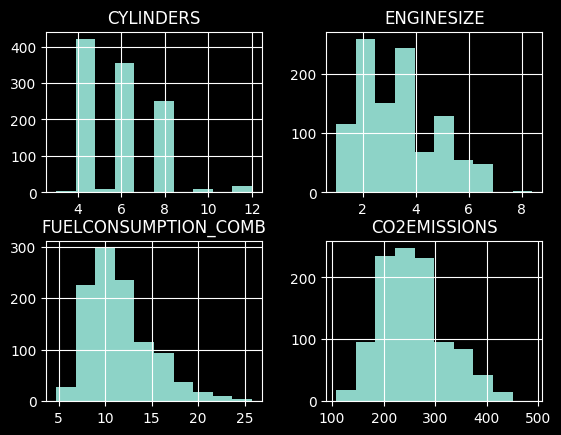

In [33]:
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
viz.hist()
plt.show()

As we can see, most engines have 4, 6, or 8 cylinders, and engine sizes between
2 and 4 liters.
As one might expect, combined fuel consumption and CO2 emission have very
similar distributions.
Let's now display some scatter plots of these features against the CO2
emissions, to see how linear their relationships are.


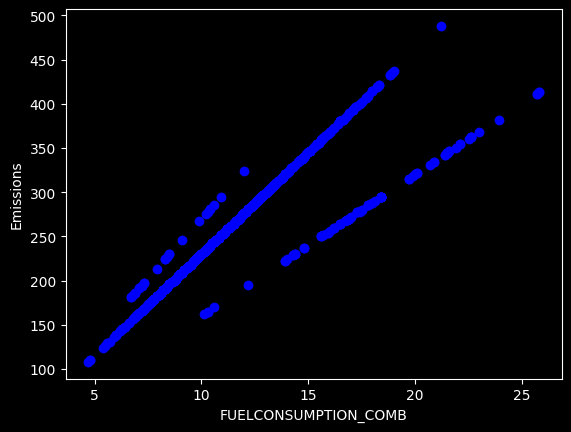

In [34]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('Emissions')
plt.show()

This is an informative result. The data appears to form **three distinct bands** — this is because there are three fuel types in the dataset (regular gasoline, premium gasoline, and diesel), each with its own CO2-per-litre ratio. Within each band, the relationship between fuel consumption and CO2 emission is strongly linear, which makes intuitive sense: burning more fuel always produces more CO2.

Overall, combined fuel consumption looks like a strong predictor of CO2 emissions.

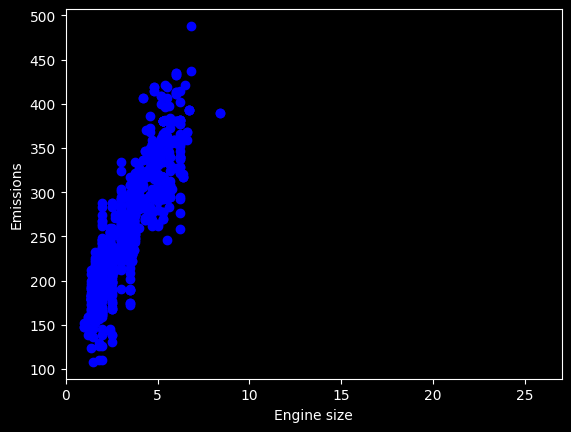

In [35]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('Engine size')
plt.ylabel('Emissions')
# xlim is set wide to match the fuel consumption plot's x-axis scale for easier visual comparison
plt.xlim(0, 27)
plt.show()

The relationship between engine size and CO2 emission is broadly linear, but the points are more spread out (more variance) compared to the tight bands in the fuel consumption plot. This suggests engine size is a reasonable predictor of CO2 emissions, but not as precise as fuel consumption — which makes sense because a large engine driven conservatively may emit less CO2 than a smaller engine driven hard.

## Practice exercise 1
Plot __CYLINDER__ against CO2 Emissions, to see how linear their relationship is.

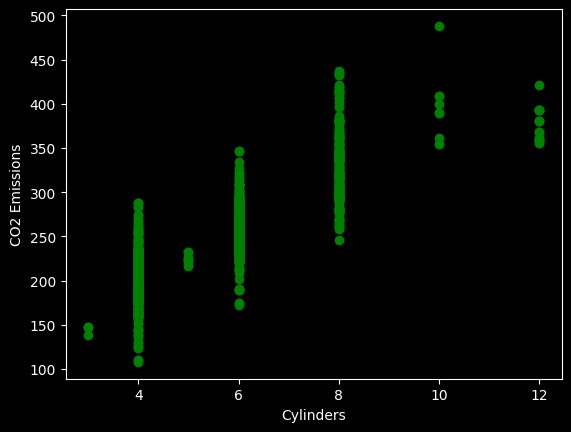

In [36]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='green')
plt.xlabel('Cylinders')
plt.ylabel('CO2 Emissions')
plt.show()

The cylinders scatter shows a weaker linear relationship than engine size or fuel consumption. Because cylinder count only takes a small number of discrete values (4, 6, 8, etc.), the data clusters into vertical columns rather than spreading smoothly, which makes it a less ideal feature for simple linear regression.

### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature,
for illustration purposes, we will use engine size to predict CO2 emission
with a linear regression model.

We can begin the process by extracting the input feature and target output
variables, `X` and `y`, from the dataset.

In [37]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create, train, and test datasets
Next, we will split the dataset into mutually exclusive training and testing
sets. We will train a simple linear regression model on the training set
and estimate its ability to generalize to unseen data by using it to make
predictions on the unseen testing data.

Since the outcome of each data point is part of the testing data, we have
a means of evaluating the out-of-sample accuracy of our model.

Now, we want to randomly split our data into train and test sets, using 80%
of the dataset for training and reserving the remaining 20% for testing. Which
fraction to use here mostly depends on the size of your data, but typical
testing sizes range from 20% to 30%. The smaller your data, the larger our
training set needs to be because it's easier to find spurious patterns
in smaller data. The downside is that our evaluation of generalizability
will have less reliability. Bigger is better when it comes to data.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.

In [39]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (853,), (853,))

### Build a simple linear regression model

We'll use scikit-learn to build our model as follows.
See [Scikit-Learn Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
to learn all about the linear model predictor object.


In [40]:
from sklearn import linear_model

# Create a model object
regressor = linear_model.LinearRegression()

# Train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input
# for the training data, with shape (n_observations, n_features).
# So, we need to reshape it. We can let it infer the number of observations
# using `-1`.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print('Coefficients: \n', regressor.coef_[0]) # with simple linear regression, there's only one coefficient, here we extract it from the 1 by 1 array
print('Intercept: \n', regressor.intercept_)

Coefficients: 
 38.992978724434046
Intercept: 
 126.2897021740873


Here, **Coefficient** and **Intercept** are the regression parameters ($\theta_1$ and $\theta_0$) determined by the model.

They define the slope and intercept of the best-fit line through the training data.

**Concretely for our model:**
- **Intercept ≈ 126.3** — a car with an engine size of 0L would be predicted to emit ~126 g/km of CO2 (not physically meaningful, but it anchors the line)
- **Coefficient ≈ 39.0** — for every additional **1 litre** of engine size, the model predicts CO2 emissions increase by about **39 g/km**

So for example, a 3.0L engine would be predicted to emit roughly $126.3 + 39.0 \times 3.0 \approx 243$ g/km.

### Visualize model outputs

We can visualize the goodness-of-fit of the model to the training data
by plotting the fitted line over the data.

The regression model is the line given by `y = intercept + coefficient * x`.


Text(0, 0.5, 'CO2 Emissions')

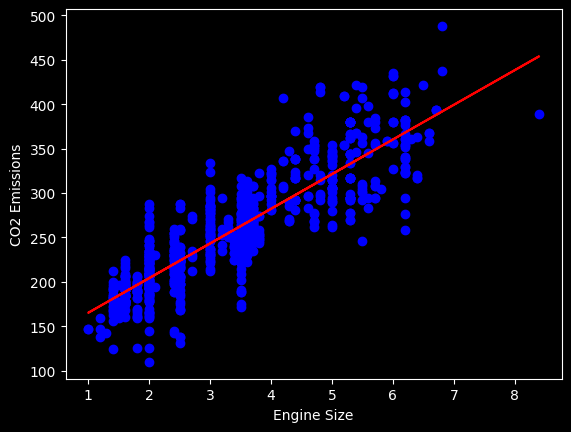

In [41]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')

#### Model evaluation
We can compare the actual values and predicted values to calculate
the accuracy of a regression model. Evaluation metrics play a key role
in the development of a model, as they provide insight into areas
that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate
the accuracy of our model based on the test set:
* Mean Absolute Error: It is the mean of the absolute value of the errors.
  This is the easiest of the metrics to understand since it’s just an average
  error.
* Mean Squared Error (MSE): MSE is the mean of the squared error. In fact,
  it's the metric used by the model to find the best fit line,
  and for that reason, it is also called the residual sum of squares.
* Root Mean Squared Error (RMSE). RMSE simply transforms the MSE into the same
  units as the variables being compared, which can make it easier to interpret.
* R2-Score is not an error but rather a popular metric used to estimate
  the performance of our regression model. It represents how close the data
  points are to the fitted regression line. The higher the R2-Score value,
  the better the model fits our data. The best possible score is 1.0,
  and it can be negative (because the model can be arbitrarily worse).


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1, 1))

# Evaluation
print("Mean Absolute Error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score: %.2f" % r2_score(y_test, y_pred))

Mean Absolute Error: 24.10
Mean Squared Error: 985.94
Root Mean Squared Error: 31.40
R2 Score: 0.76


**Interpreting the results:**

- **MAE ≈ 24.1 g/km** — on average, our predictions are off by about 24 g/km. Given that CO2 values in this dataset range from ~108 to 488 g/km (a spread of 380), this is a moderate error.
- **RMSE ≈ 31.4 g/km** — similar story to MAE, but RMSE penalizes large errors more heavily. The fact that RMSE > MAE tells us there are some predictions that are quite far off.
- **R² ≈ 0.76** — the model explains about **76% of the variance** in CO2 emissions using engine size alone. An R² of 1.0 would mean perfect predictions; 0.0 would mean the model does no better than just predicting the mean every time. 0.76 is a reasonable result for a single-feature model.

In the next section, we'll check whether using fuel consumption instead of engine size gives a better fit — which the exploratory scatter plots suggested it should.

## Practice exercises

#### 1. Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.


Text(0, 0.5, 'CO2 Emissions')

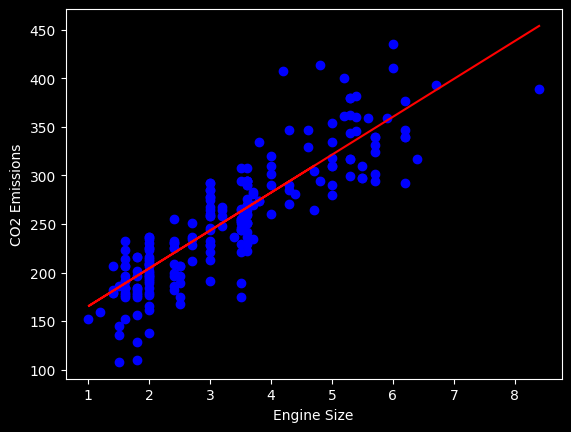

In [43]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')

Let's see the evaluation metrics if we train a regression model using
the `FUELCONSUMPTION_COMB` feature.

#### 2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets.
Use the same random state as previously so you can make an objective comparison
to the previous training result.


In [44]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 3.  Train a linear regression model using the training data we just created.
Remember we need to transform the 1D feature into a 2D array.

In [45]:
regr = linear_model.LinearRegression()
regr.fit(X_train.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 4. Use the model to make test predictions on the fuel consumption testing data.


In [46]:
y_pred = regr.predict(X_test.reshape(-1, 1))

#### 5. Calculate and print all four evaluation metrics for the fuel consumption model: MAE, MSE, RMSE, and R².


In [48]:
print("Mean Absolute Error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score: %.2f" % r2_score(y_test, y_pred))

Mean Absolute Error: 20.44
Mean Squared Error: 797.43
Root Mean Squared Error: 28.24
R2 Score: 0.81


**Interpreting the results:**

- **MAE** — on average, our predictions are off by about 20 g/km, down from ~24 g/km with engine size.
- **RMSE** — also lower than for engine size, confirming fewer large prediction errors.
- **R²** — the model explains a higher percentage of the variance in CO2 emissions than the engine size model did. This confirms what the scatter plots suggested: fuel consumption is a stronger predictor.

Notice that all error metrics went *down* and R² went *up* — every indicator points in the same direction, which gives us confidence the improvement is real.

#### 6. Plot the fuel consumption regression line over the test data (like Exercise 1 did for engine size). Does the fit look better visually?

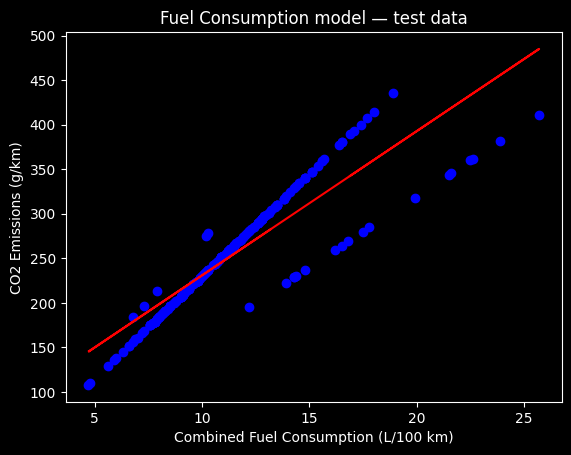

In [49]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, regr.coef_ * X_test + regr.intercept_, '-r')
plt.xlabel('Combined Fuel Consumption (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')
plt.title('Fuel Consumption model — test data')
plt.show()

#### 7. Compare both models side by side and explain why one outperforms the other.

Run the cell below to print a comparison table, then read the explanation that follows.

In [50]:
# Engine size metrics (computed earlier in this notebook)
engine_size_results = {
    'MAE':  24.10,
    'MSE':  985.94,
    'RMSE': 31.40,
    'R2':   0.76,
}

# Fuel consumption metrics (computed just above)
fuel_comb_results = {
    'MAE':  mean_absolute_error(y_test, y_pred),
    'MSE':  mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2':   r2_score(y_test, y_pred),
}

print(f"{'Metric':<6} {'Engine Size':>14} {'Fuel Consumption':>18} {'Winner':>14}")
print("-" * 56)
for metric, (es, fc) in zip(
    engine_size_results.keys(),
    zip(engine_size_results.values(), fuel_comb_results.values())
):
    # Lower error is better; higher R² is better
    fuel_wins = fc < es if metric != 'R2' else fc > es
    winner = 'Fuel Comb.' if fuel_wins else 'Engine Size'
    print(f"{metric:<6} {es:>14.2f} {fc:>18.2f} {winner:>14}")

Metric    Engine Size   Fuel Consumption         Winner
--------------------------------------------------------
MAE             24.10              20.44     Fuel Comb.
MSE            985.94             797.43     Fuel Comb.
RMSE            31.40              28.24     Fuel Comb.
R2               0.76               0.81     Fuel Comb.


**Why does fuel consumption outperform engine size?**

The short answer is that fuel consumption is **causally closer** to CO2 emissions than engine size is.

CO2 emissions are a direct chemical consequence of burning fuel: every litre of gasoline burned produces a fixed amount of CO2 regardless of what car it's burned in. So if you know how much fuel a car consumes, you can calculate its CO2 emissions almost exactly — the relationship is essentially a physical law, not just a statistical correlation. This is exactly why the fuel consumption scatter plot showed three very tight, near-perfect lines (one per fuel type).

Engine size, on the other hand, only *influences* fuel consumption — it doesn't determine it directly. A large-engine car driven gently on a highway can consume less fuel (and emit less CO2) than a small-engine car stuck in city traffic. Engine size is therefore a **proxy** for CO2 emissions, with many confounding factors (driving style, transmission type, aerodynamics, weight) adding noise to the relationship.

In machine learning terms:
- A feature that is **causally linked** to the target will almost always produce a better model than one that is merely **correlated** with it.
- The scatter plots were our early warning: tight clusters → better predictor, wide spread → more noise → worse model.